In [2]:
import pandas as pd

df = pd.read_csv("../data/british_airways_reviews 2.csv")

df.head()

,Unnamed: 0,title,reviews
0,0,"""unprofessional attitude of the pilots""",BA 246 21JAN 2023 Did not appreciate the unp...
1,1,“Next time it will be Jet2”,Not a great experience. I could not check in ...
2,2,“become the Ryanair of long-haul travel”,I was excited to fly BA as I'd not travelled ...
3,3,“They never help us”,I just want to warn everyone of the worst cu...
4,4,“uncomfortable seat and disgusting food”,Paid for business class travelling Cairo to L...


In [3]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(1300, 3)


In [4]:
df.isnull().sum()

Unnamed: 0    0
title         0
reviews       0
dtype: int64

In [6]:
df["reviews"].sample(5)


1166     Flew London Gatwick to Tirana Rinas. Bag drop...
938       London City to Zurich, I fly this route a lo...
767      Amman to London. This is a nice aircraft, wit...
1110      Johannesburg to London. I tend to stay with ...
281       A rather empty and quiet flight to Tel Aviv,...
Name: reviews, dtype: str

In [7]:
df["review_length"] = df["reviews"].str.len()

df["review_length"].describe()

count    1300.000000
mean      827.796923
std       568.608582
min       131.000000
25%       428.750000
50%       682.500000
75%      1047.250000
max      3491.000000
Name: review_length, dtype: float64

In [8]:
import nltk

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/codespace/nltk_data...


True

In [9]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

sample_review = df["reviews"][0]

sia.polarity_scores(sample_review)

{'neg': 0.061, 'neu': 0.869, 'pos': 0.07, 'compound': 0.5013}

In [10]:
df["sentiment_score"] = df["reviews"].apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)

df[["title", "sentiment_score"]].head()

,title,sentiment_score
0,"""unprofessional attitude of the pilots""",0.5013
1,“Next time it will be Jet2”,0.8749
2,“become the Ryanair of long-haul travel”,0.4770
3,“They never help us”,-0.9357
4,“uncomfortable seat and disgusting food”,-0.9686


In [11]:
df["sentiment_score"].describe()

count    1300.000000
mean        0.051315
std         0.788455
min        -0.997400
25%        -0.787075
50%         0.098300
75%         0.908425
max         0.999200
Name: sentiment_score, dtype: float64

In [12]:
def classify_satisfaction(score):
    if score >= 0.05:
        return "Satisfied"
    elif score <= -0.05:
        return "Unsatisfied"
    else:
        return "Neutral"

df["satisfaction_label"] = df["sentiment_score"].apply(classify_satisfaction)

df[["title", "sentiment_score", "satisfaction_label"]].head()

,title,sentiment_score,satisfaction_label
0,"""unprofessional attitude of the pilots""",0.5013,Satisfied
1,“Next time it will be Jet2”,0.8749,Satisfied
2,“become the Ryanair of long-haul travel”,0.4770,Satisfied
3,“They never help us”,-0.9357,Unsatisfied
4,“uncomfortable seat and disgusting food”,-0.9686,Unsatisfied


In [13]:
df["satisfaction_label"].value_counts()

satisfaction_label
Satisfied      655
Unsatisfied    628
Neutral         17
Name: count, dtype: int64

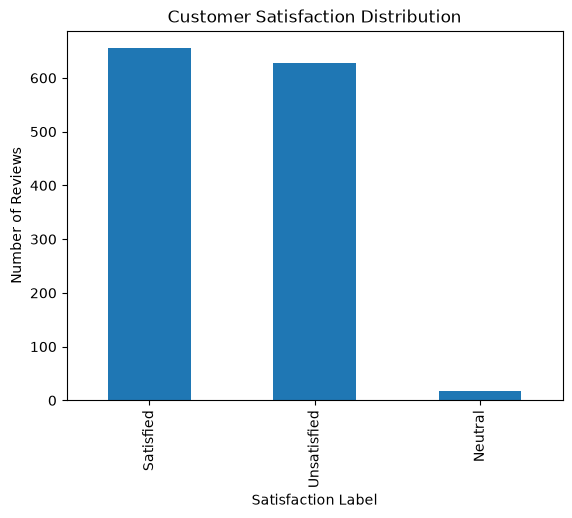

In [14]:
import matplotlib.pyplot as plt

df["satisfaction_label"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Satisfaction Distribution")
plt.xlabel("Satisfaction Label")
plt.ylabel("Number of Reviews")
plt.show()

In [15]:
from collections import Counter
import re

negative_reviews = df[df["satisfaction_label"] == "Unsatisfied"]

all_text = " ".join(negative_reviews["reviews"].astype(str))

words = re.findall(r'\b[a-zA-Z]+\b', all_text.lower())

common_words = Counter(words)

common_words.most_common(30)

[('the', 4625),
 ('to', 3683),
 ('and', 2707),
 ('i', 2216),
 ('a', 2031),
 ('was', 1845),
 ('in', 1350),
 ('flight', 1249),
 ('of', 1242),
 ('for', 1192),
 ('on', 1101),
 ('my', 929),
 ('they', 927),
 ('we', 899),
 ('with', 895),
 ('that', 892),
 ('not', 820),
 ('ba', 820),
 ('it', 751),
 ('is', 718),
 ('had', 685),
 ('no', 681),
 ('at', 649),
 ('were', 614),
 ('have', 579),
 ('this', 562),
 ('but', 529),
 ('me', 511),
 ('from', 497),
 ('as', 467)]

In [16]:
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

filtered_words = [
    word for word in words
    if word not in stop_words and len(word) > 2
]

common_filtered = Counter(filtered_words)

common_filtered.most_common(30)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[('flight', 1249),
 ('service', 439),
 ('london', 404),
 ('british', 308),
 ('airways', 302),
 ('seat', 299),
 ('one', 293),
 ('hours', 291),
 ('class', 285),
 ('time', 272),
 ('staff', 271),
 ('business', 263),
 ('get', 261),
 ('seats', 256),
 ('would', 248),
 ('customer', 239),
 ('food', 238),
 ('told', 226),
 ('heathrow', 225),
 ('airline', 223),
 ('check', 219),
 ('airport', 199),
 ('plane', 195),
 ('even', 190),
 ('back', 189),
 ('could', 187),
 ('crew', 185),
 ('flights', 184),
 ('hour', 180),
 ('cabin', 174)]

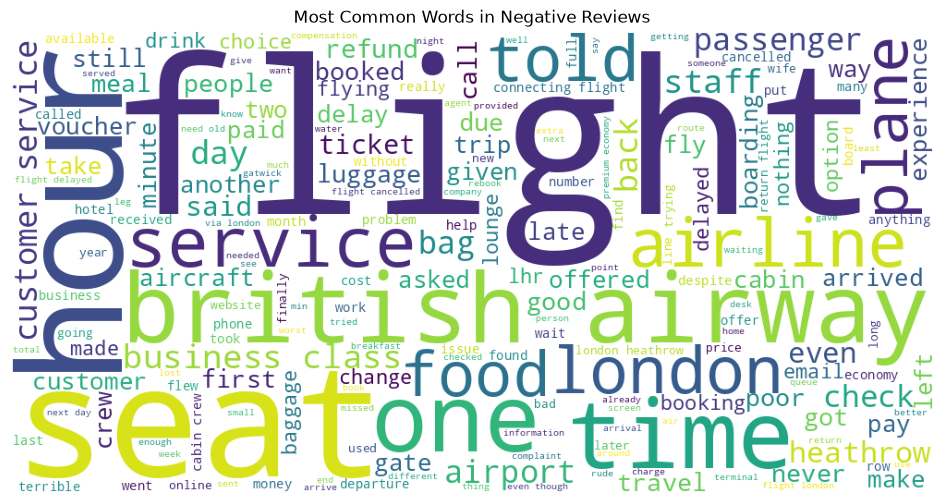

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(" ".join(filtered_words))

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Common Words in Negative Reviews")
plt.show()

In [18]:
top_topics = [
    "Flight Delays",
    "Customer Service",
    "Seat Comfort",
    "Food Quality",
    "Airport Experience"
]

for topic in top_topics:
    print(f"Topic: {topic}")

Topic: Flight Delays
Topic: Customer Service
Topic: Seat Comfort
Topic: Food Quality
Topic: Airport Experience


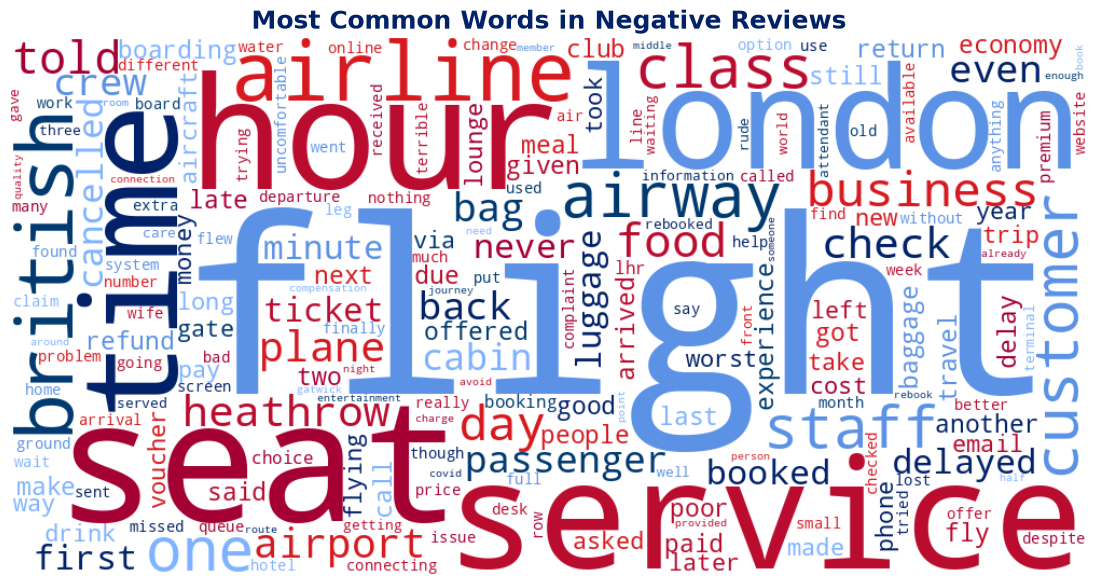

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import random

# British Airways inspired color palette
ba_colors = [
    "#012169",  # British Airways Navy Blue
    "#003A70",  # Dark Blue
    "#5B92E5",  # Light Blue
    "#7FB3FF",  # Sky Blue
    "#BA0C2F",  # British Airways Red
    "#A50034",  # Dark Red
    "#D71920",  # Bright Red
]

# Function that randomly assigns colors from the BA palette
def ba_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return random.choice(ba_colors)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    collocations=False
).generate(" ".join(filtered_words_v2))

# Apply custom colors
wordcloud = wordcloud.recolor(color_func=ba_color_func)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(
    "Most Common Words in Negative Reviews",
    fontsize=18,
    fontweight="bold",
    color="#012169"
)
plt.show()

In [20]:
custom_stopwords = {
    "one",
    "would",
    "could",
    "even",
    "still",
    "also",
    "really",
    "get",
    "got",
    "back",
    "said",
    "made",
    "make",
    "first",
    "last",
    "next",
    "day",
    "people",
    "time"
}

filtered_words_v2 = [
    word for word in filtered_words
    if word not in custom_stopwords
]

In [21]:
" ".join(filtered_words_v2)

'want warn everyone worst customer service experience ever looks like british airways customer service phone trained help anyway create problems rather solving week called british airways reservation family explained customer service representative wanted booking pay transfer miles american express representative told reservation miles account asked contact american express transfer booking conversation recorded british airways checked immediately called amex within minutes solicited transfer miles amex clearly stated whether sure transfer reversible fine since checked previously british airways called british airways immediately reservation miami confirmed miles arrived account surprise told space seat miami use miles explained situation led believe flight miles transferred miles went deaf ears called german office absolutely unhelpful called customer service unhelpful manager able open flight miles kept repeating possible though paid flight seats seats available gold status end briti

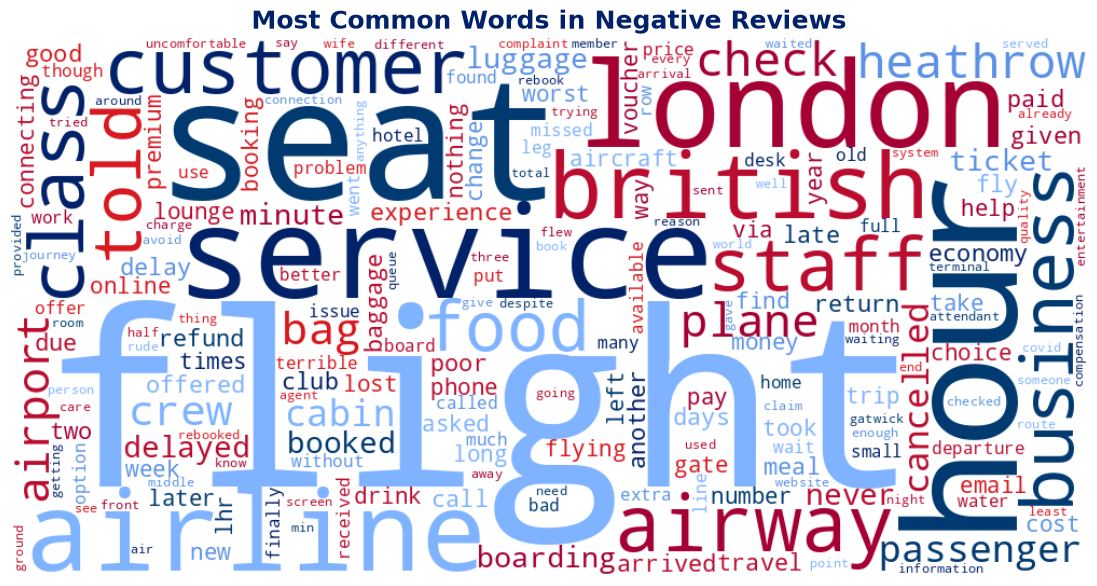

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import random

# British Airways inspired color palette
ba_colors = [
    "#012169",  # British Airways Navy Blue
    "#003A70",  # Dark Blue
    "#5B92E5",  # Light Blue
    "#7FB3FF",  # Sky Blue
    "#BA0C2F",  # British Airways Red
    "#A50034",  # Dark Red
    "#D71920",  # Bright Red
]

# Function that randomly assigns colors from the BA palette
def ba_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return random.choice(ba_colors)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    collocations=False
).generate(" ".join(filtered_words_v2))

# Apply custom colors
wordcloud = wordcloud.recolor(color_func=ba_color_func)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(
    "Most Common Words in Negative Reviews",
    fontsize=18,
    fontweight="bold",
    color="#012169"
)
plt.show()

In [23]:
additional_stopwords = {
    "london",
    "heathrow",
    "british",
    "airways",
    "airway"
}

In [24]:
recommendations = {
    "Flight Delays": "Improve proactive communication during delays, provide real-time updates, and offer compensation when disruptions occur.",
    
    "Customer Service": "Increase customer service training, reduce response times, and empower staff to resolve issues more efficiently.",
    
    "Seat Comfort": "Review seat quality, cabin maintenance, and passenger comfort standards, especially in premium cabins.",
    
    "Food Quality": "Expand menu options, improve consistency of meal quality, and gather passenger feedback on food offerings.",
    
    "Airport Experience": "Streamline check-in, boarding, and baggage processes to reduce passenger frustration."
}

for category, recommendation in recommendations.items():
    print(f"\n📌 {category}")
    print(f"Recommendation: {recommendation}")


📌 Flight Delays
Recommendation: Improve proactive communication during delays, provide real-time updates, and offer compensation when disruptions occur.

📌 Customer Service
Recommendation: Increase customer service training, reduce response times, and empower staff to resolve issues more efficiently.

📌 Seat Comfort
Recommendation: Review seat quality, cabin maintenance, and passenger comfort standards, especially in premium cabins.

📌 Food Quality
Recommendation: Expand menu options, improve consistency of meal quality, and gather passenger feedback on food offerings.

📌 Airport Experience
Recommendation: Streamline check-in, boarding, and baggage processes to reduce passenger frustration.


In [25]:
import pandas as pd

recommendations_df = pd.DataFrame(
    recommendations.items(),
    columns=["Complaint Category", "Recommended Action"]
)

recommendations_df

,Complaint Category,Recommended Action
0,Flight Delays,"Improve proactive communication during delays,..."
1,Customer Service,"Increase customer service training, reduce res..."
2,Seat Comfort,"Review seat quality, cabin maintenance, and pa..."
3,Food Quality,"Expand menu options, improve consistency of me..."
4,Airport Experience,"Streamline check-in, boarding, and baggage pro..."


In [26]:
new_review = """
The flight was delayed for three hours and customer service was unhelpful.
"""

score = sia.polarity_scores(new_review)["compound"]

print("Sentiment Score:", score)

Sentiment Score: -0.2263


In [27]:
def predict_satisfaction(review_text):
    
    score = sia.polarity_scores(review_text)["compound"]
    
    if score >= 0.05:
        label = "Satisfied"
    elif score <= -0.05:
        label = "Unsatisfied"
    else:
        label = "Neutral"
        
    return score, label

In [28]:
review = """
The flight was delayed for three hours and customer service was unhelpful.
"""

score, label = predict_satisfaction(review)

print("Sentiment Score:", score)
print("Prediction:", label)

Sentiment Score: -0.2263
Prediction: Unsatisfied


In [29]:
review = """
The flight was delayed for three hours and customer service was unhelpful.
"""

score, label = predict_satisfaction(review)

print("Review:")
print(review)

print("\nSentiment Score:", round(score, 3))
print("Predicted Satisfaction:", label)

Review:

The flight was delayed for three hours and customer service was unhelpful.


Sentiment Score: -0.226
Predicted Satisfaction: Unsatisfied
